---
title: Advanced Algorithms - Greedy Search and Greedy Randomized Adaptive Search Procedure (GRASP)
toc: true
image: image.png
execute: 
  enabled: true
---


Brute force algorithms are effective up to a certain point, but it can quickly become impossible to evaluate all possible combinations of sites as the possible number of combinations grows very quickly. 

For example, let's imagine you have 30 possible places to put a site, but you only want 1 site. That's 30 combinations to try. 

If you want 2 sites from those 30 possibilities, that's 435 combinations to try. 

3 sites from those 30 possibilities is 4060 combinations...

4 is 27,405 combinations...

5 is 142,506 combinations...

6 is 75,287,520 combinations! 

In [1]:
#| echo: false
import pandas as pd
import math

combos_df = pd.DataFrame(
    [{"n_sites_to_include": i, "total_n_sites": 30, "combinations": int(math.factorial(30)/(math.factorial(30-i) * math.factorial(i)))} for i in range(1,30)]

)

combos_df

,n_sites_to_include,total_n_sites,combinations
0,1,30,30
1,2,30,435
2,3,30,4060
3,4,30,27405
4,5,30,142506
5,6,30,593775
6,7,30,2035800
7,8,30,5852925
8,9,30,14307150
9,10,30,30045015


For our 30 site problem, if we want a total of 15 sites, we can see that's nearly 160 **million** combinations to evaluate.  

In [2]:
# echo: false
import plotly.express as px

px.bar(combos_df, x="n_sites_to_include", y="combinations")

While we can handle the memory implications of trying to evaluate that many combinations using the `keep_best_n` and `keep_worst_n` arguments in .solve() so we're not storing every single result, it's still going to take an extremely long time to evaluate that many solutions. 

Instead, we can turn to some different possible solutions, which we'll explore in these notebooks. 

## Greedy Search

Greedy search works quite simply. 

Let's imagine we wanted to find a good solution to our n=15 problem. 

We'd start by working out the best solution for 1 site (i.e. what single site gives us the best result). 

We'd then take work out the best possible combination of 2 sites - where 1 site must be the site we found from the first round. 

Then we keep going, repeating this process all the way up to the final number of sites. 

:::{.callout-note}
Because the greedy algorithm is short-sighted - it always takes the best possible next move - it will find a 'good' solution, but it may well not find the 'best' solution - or even one of the best. 

We describe this as 'getting stuck in a local optimum'. 
:::

In [3]:
from lokigi.site import SiteProblem

problem_small = SiteProblem()

problem_small.add_sites(
    "../../../sample_data/brighton_sites_named.geojson",
    candidate_id_col="site"
    )

problem_small.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

problem_small.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    # "../../../sample_data/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

In [4]:
solution_small_greedy = problem_small.solve(p=3, search_strategy="greedy")

C:\lokigi\lokigi\site.py:591: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal.If you wish to override this, run .add_demand() to add your site dataframe before running .solve() again.You can use the .show_demand_format() to see the expected format beforehand.
  warn(


  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [5]
Best combination for 2 sites: [2 5]
Best combination for 3 sites: [2 3 5]


In [5]:
solution_small_greedy

In [6]:
solution_small_greedy.return_best_combination_details()

,index,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,0,None,"[2, 3, 5]",None,5.357941,5.357941,8.055933,16.688833,0.0,LSOA L...


<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

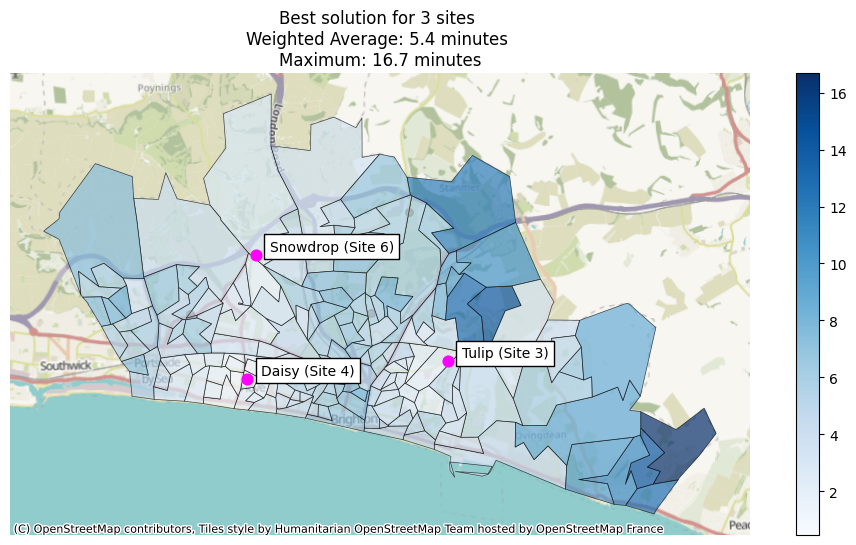

In [7]:
solution_small_greedy.plot_best_combination()

Let's now compare this with the best solution from our brute force approach. 

  0%|          | 0/20 [00:00<?, ?it/s]

<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

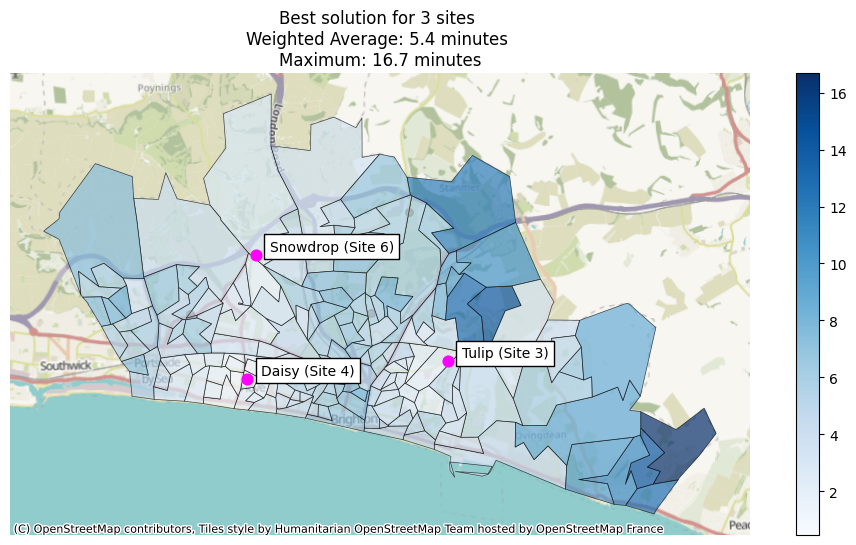

In [8]:
solution_small_brute_force = problem_small.solve(p=3, search_strategy="brute-force")
solution_small_brute_force.plot_best_combination()

Let's see if the solution differs with different objectives. 

  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [2]
Best combination for 2 sites: [2 3]
Best combination for 3 sites: [2 3 5]


<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

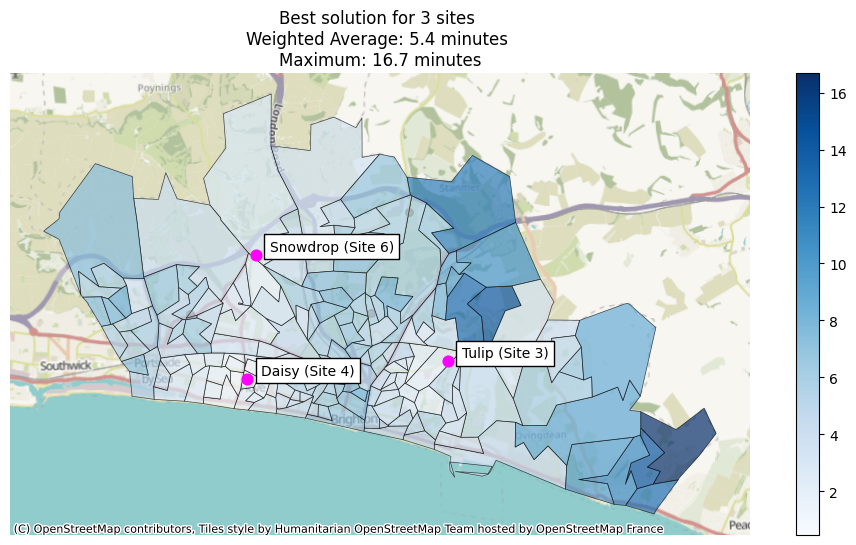

In [9]:
solution_small_greedy_p_center = problem_small.solve(p=3, search_strategy="greedy", objectives="p_center")
solution_small_greedy_p_center.plot_best_combination()

  0%|          | 0/3 [00:00<?, ?it/s]

Best combination for 1 sites: [5]
Best combination for 2 sites: [2 5]
Best combination for 3 sites: [2 3 5]


<Axes: title={'center': 'Best solution for 3 sites \nCoverage within threshold of 8 minutes: 89.7% \nUnweighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

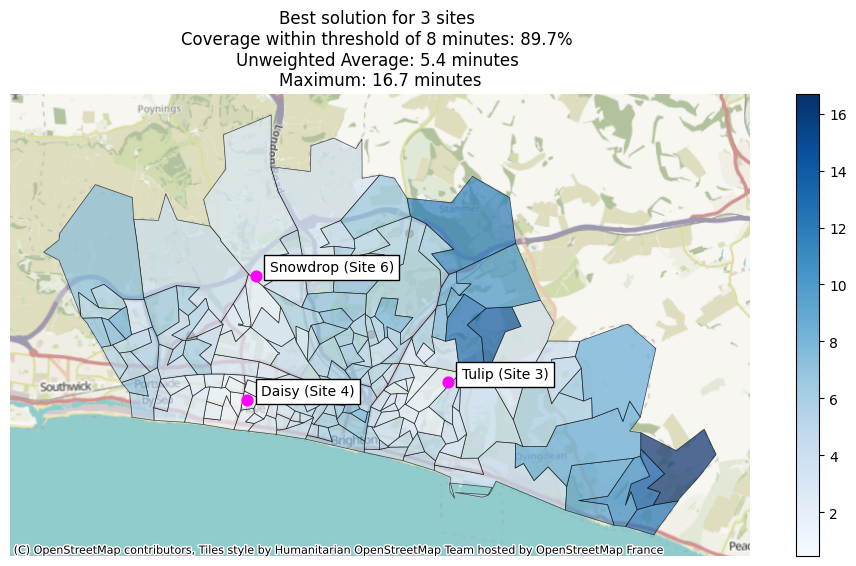

In [10]:
solution_small_greedy_mclp = problem_small.solve(p=3, search_strategy="greedy", objectives="mclp", threshold_for_coverage=8)
solution_small_greedy_mclp.plot_best_combination()

Interestingly, when we compare our MCLP problem (maximising coverage location problem) and p-center (minimising the maximum travel distance), we end up with the same result, but the order the sites were added in changed! 

For MCLP, the best single-site combination is site index 5 (which corresponds to site 6 due to Python's zero indexing), with site indices 2 and 3 being added in the second and third pass respectively. 

In contrast, for p-center, it's site index 2 (corresponding to site 3 - Tulip) that's the best for a single site solution. 

## Greedy search on a larger problem

For the problem we've been working with so far, greedy search isn't really that useful as there are a small enough number of sites that for any value of p, we can brute force (evaluate every single possible combination) without difficulty. 

The value of the greedy search becomes much more apparent when we look at a bigger problem. 

In [11]:
problem = SiteProblem()

problem.add_demand("https://github.com/health-data-science-OR/healthcare-logistics/blob/master/optimisation/data/sh_demand.csv", demand_col="n_patients", location_id_col="sector")
problem.add_travel_matrix("https://github.com/health-data-science-OR/healthcare-logistics/blob/master/optimisation/data/clinic_car_travel_time.csv", source_col="sector")

In [12]:
problem.total_n_sites

With a total of 28 sites, if we were to solve for 10 sites, we would need to evaluate...

In [13]:
print(f"{int(math.factorial(30)/(math.factorial(30-10) * math.factorial(10))):,d}")

30,045,015


sites. That's a lot of sites!

However, using the greedy algorithm, we can get a solution we can be reasonably confident is somewhat decent fairly quickly. 

While we can't pass in a maximum travel time threshold for our greedy algorithm, we can pass in the `threshold_for_coverage` parameter to calculate the proportion of regions that meet a given target travel time. 

In [30]:
solution_greedy = problem.solve(p=10, search_strategy="greedy", threshold_for_coverage=10)
solution_greedy

  0%|          | 0/10 [00:00<?, ?it/s]

Best combination for 1 sites: [3]
Best combination for 2 sites: [3 7]
Best combination for 3 sites: [ 3  7 11]
Best combination for 4 sites: [ 3  4  7 11]
Best combination for 5 sites: [ 3  4  7  8 11]
Best combination for 6 sites: [ 3  4  7  8 10 11]
Best combination for 7 sites: [ 3  4  7  8 10 11 22]
Best combination for 8 sites: [ 3  4  7  8 10 11 17 22]
Best combination for 9 sites: [ 3  4  7  8 10 11 17 22 24]
Best combination for 10 sites: [ 3  4  7  8 10 11 15 17 22 24]


In [ ]:
solution_greedy.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[3, 4, 7, 8, 10, 11, 15, 17, 22, 24]",None,6.81,10.0,19.43,32.37,0.0,sector sector_x clinic_4 clinic_5 clini...


## GRASP

As we can see from the above, while we can now tackle much larger problems than before, we get a single deterministic output from the greedy search problem. This isn't ideal - we can't provide multiple near-optimum solutions to our stakeholders, and we have no idea how good our solution is - is it stuck in a local optimum a long way from the global optimum? 

Enter GRASP - Greedy Randomised Adaptive Search Procedure. 

In [18]:
solution = problem.solve(p=10, search_strategy="grasp", threshold_for_coverage=10)


Finding unique solutions:   0%|          | 0/5 [00:00<?, ?it/s]

In [19]:
solution.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[3, 4, 7, 8, 10, 11, 14, 17, 22, 27]",10,6.86,9.91,18.51,32.37,0.60,sector sector_x clinic_4 clinic_5 clini...
1,None,"[3, 4, 7, 8, 10, 11, 13, 14, 22, 24]",10,6.97,9.97,19.53,32.37,0.61,sector sector_x clinic_4 clinic_5 clini...
2,None,"[3, 4, 7, 11, 12, 13, 14, 21, 22, 24]",10,7.18,10.07,19.53,32.37,0.60,sector sector_x clinic_4 clinic_5 clini...
3,None,"[1, 3, 4, 5, 9, 11, 12, 15, 17, 21]",10,7.20,10.51,22.03,32.37,0.59,sector sector_x clinic_2 clinic_4 clini...
4,None,"[3, 4, 6, 7, 11, 12, 13, 14, 21, 27]",10,7.47,10.63,22.16,32.37,0.58,sector sector_x clinic_4 clinic_5 clini...


Let's compare this to the best solution found by the pure greedy algorithm:

In [32]:
solution_greedy.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[3, 4, 7, 8, 10, 11, 15, 17, 22, 24]",None,6.81,10.0,19.43,32.37,0.0,sector sector_x clinic_4 clinic_5 clini...


Interestingly this doesn't show up in our top 5 solutions found with GRASP, and is better than any of them (though only marginally)! So it's worth considering whether to run both. 

In addition, it would benefit us to run GRASP with a higher number of maximum iterations and a slightly higher alpha to get a more diverse solution pool. In the interests of it not taking forever to regenerate this documentation, below we show a screenshot of the outputs when we've run GRASP for much longer.  

In [ ]:
# solution_grasp_big = problem.solve(
#     p=10, search_strategy="grasp", threshold_for_coverage=10, grasp_alpha=0.6,
#     grasp_max_attempts=5000, grasp_num_solutions=20
#     )

Finding unique solutions:   0%|          | 0/20 [00:00<?, ?it/s]

### GRASP on our smaller problem - does it find the known optimal solution in this case? 

Let's also try this out on our smaller problem from earlier - do we find the optimal solution here too?

In [20]:
solution_small_grasp = problem_small.solve(p=3, search_strategy="grasp")

Finding unique solutions:   0%|          | 0/5 [00:00<?, ?it/s]

In [21]:
solution_small_grasp.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...


<Axes: title={'center': 'Best solution for 3 sites \nWeighted Average: 5.4 minutes \nMaximum: 16.7 minutes'}>

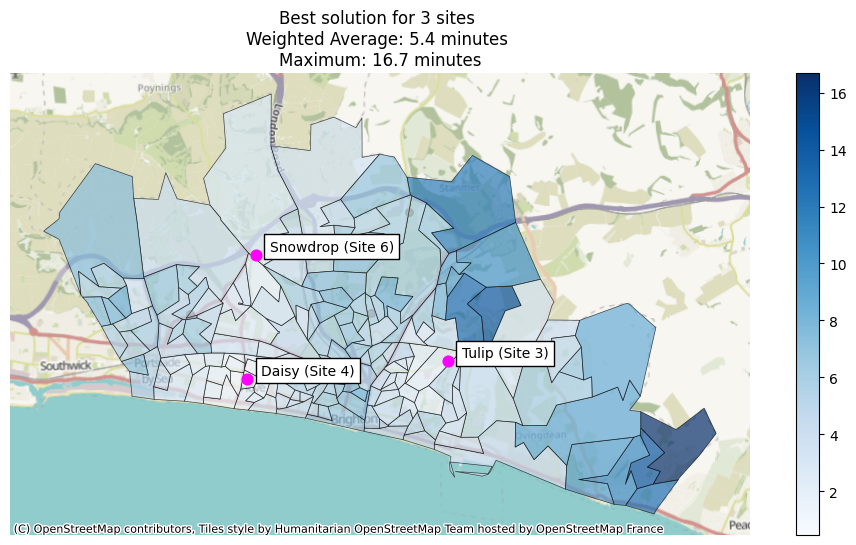

In [22]:
solution_small_grasp.plot_best_combination()

It gets very stuck with the default alpha value, finding the same solution over and over again! Let's turn up the alpha and see if we can get some more varied solutions out. 

In [23]:
solution_small_grasp_higher_alpha = problem_small.solve(
    p=3, search_strategy="grasp",
    grasp_alpha=0.4, grasp_max_attempts=500
    )

Finding unique solutions:   0%|          | 0/5 [00:00<?, ?it/s]

In [24]:
solution_small_grasp_higher_alpha.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,None,"[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...


It looks like we need to make our alpha higher again!

In [25]:
solution_small_grasp_higher_alpha = problem_small.solve(
    p=3, search_strategy="grasp",
    grasp_alpha=0.8, grasp_max_attempts=500
    )

Finding unique solutions:   0%|          | 0/5 [00:00<?, ?it/s]

In [26]:
solution_small_grasp_higher_alpha.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,None,"[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...
2,None,"[2, 4, 5]",None,6.29,6.29,9.26,16.69,0.0,LSOA L...
3,None,"[0, 2, 4]",None,6.32,6.32,9.70,16.69,0.0,LSOA L...
4,None,"[1, 3, 4]",None,6.76,6.76,11.32,21.71,0.0,LSOA L...


Let's compare this with the best solutions from the brute force approach. 

In [27]:
solution_small_brute_force.show_solutions().head(15)

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,None,"[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...
2,None,"[1, 2, 3]",None,5.59,5.59,9.00,16.69,0.0,LSOA L...
3,None,"[0, 2, 3]",None,5.67,5.67,9.36,16.69,0.0,LSOA L...
4,None,"[0, 2, 5]",None,6.21,6.21,9.33,16.69,0.0,LSOA L...
5,None,"[2, 4, 5]",None,6.29,6.29,9.26,16.69,0.0,LSOA L...
6,None,"[1, 2, 5]",None,6.31,6.31,9.45,16.69,0.0,LSOA L...
7,None,"[0, 2, 4]",None,6.32,6.32,9.70,16.69,0.0,LSOA L...
8,None,"[0, 1, 2]",None,6.39,6.39,9.77,16.69,0.0,LSOA L...
9,None,"[1, 3, 5]",None,6.64,6.64,11.58,22.86,0.0,LSOA L...


We can see it found the
- best
- second best
- 6th best
- 8th best
- and 12th best solutions

Let's stick with a higher alpha but ask for it to find more solutions. 

In [28]:
solution_small_grasp_higher_alpha_more_sols = problem_small.solve(
    p=3, search_strategy="grasp",
    grasp_alpha=0.8, grasp_max_attempts=500,
    grasp_num_solutions=20
    )

Finding unique solutions:   0%|          | 0/20 [00:00<?, ?it/s]

In [29]:
solution_small_grasp_higher_alpha_more_sols.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,None,"[2, 3, 5]",None,5.36,5.36,8.06,16.69,0.0,LSOA L...
1,None,"[2, 3, 4]",None,5.45,5.45,8.50,16.69,0.0,LSOA L...
2,None,"[1, 2, 3]",None,5.59,5.59,9.00,16.69,0.0,LSOA L...
3,None,"[0, 2, 3]",None,5.67,5.67,9.36,16.69,0.0,LSOA L...
4,None,"[0, 2, 5]",None,6.21,6.21,9.33,16.69,0.0,LSOA L...
5,None,"[2, 4, 5]",None,6.29,6.29,9.26,16.69,0.0,LSOA L...
6,None,"[1, 2, 5]",None,6.31,6.31,9.45,16.69,0.0,LSOA L...
7,None,"[0, 2, 4]",None,6.32,6.32,9.70,16.69,0.0,LSOA L...
8,None,"[1, 3, 5]",None,6.64,6.64,11.58,22.86,0.0,LSOA L...
9,None,"[3, 4, 5]",None,6.73,6.73,12.26,21.71,0.0,LSOA L...


With an even higher alpha, we could choose to run for longer periods and be confident we're exploring a good range of the solution space without the computational overhead of the brute force method. 